In [1]:
# Install necessary libraries if not present

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Load the dataset
df = pd.read_csv('credit_risk_dataset.csv')
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset Loaded: 32581 rows, 12 columns


In [2]:
# 1. Identify Outliers: People can't be 144 years old or work for 123 years.
df = df[df['person_age'] < 100]
df = df[df['person_emp_length'] < 60]

# 2. Handle Missing Values: Use the median to fill gaps in interest rate and employment length.
df['loan_int_rate'] = df['loan_int_rate'].fillna(df['loan_int_rate'].median())
df['person_emp_length'] = df['person_emp_length'].fillna(df['person_emp_length'].median())

print("Data Cleaning Complete. Missing values:")
print(df.isnull().sum())

Data Cleaning Complete. Missing values:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64


C:\Users\pisin\AppData\Local\Temp\ipykernel_23912\3231597173.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='loan_status', data=df, palette='magma')


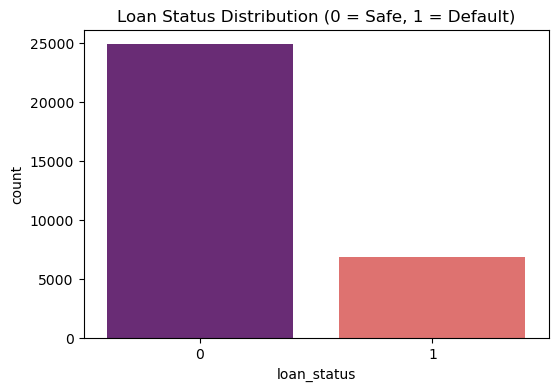

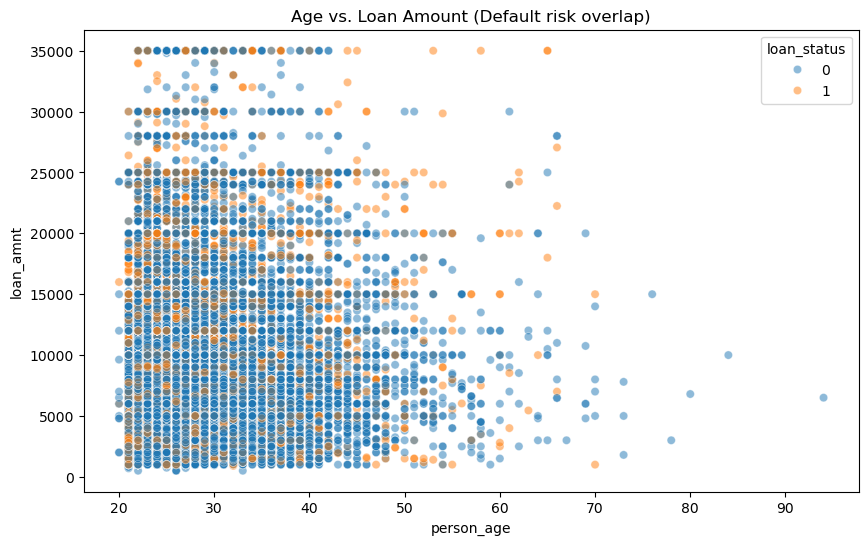

In [3]:
# Visualizing the Target Variable Imbalance
plt.figure(figsize=(6,4))
sns.countplot(x='loan_status', data=df, palette='magma')
plt.title('Loan Status Distribution (0 = Safe, 1 = Default)')
plt.show()

# Visualizing Age vs. Loan Amount colored by Status
plt.figure(figsize=(10,6))
sns.scatterplot(x='person_age', y='loan_amnt', hue='loan_status', data=df, alpha=0.5)
plt.title('Age vs. Loan Amount (Default risk overlap)')
plt.show()

In [4]:
# Convert categorical columns to numeric binary columns
# drop_first=True prevents the 'dummy variable trap'
df_encoded = pd.get_dummies(df, drop_first=True)

# Separate Features (X) and Target (y)
X = df_encoded.drop('loan_status', axis=1)
y = df_encoded['loan_status']

# Split into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)

print(f"Original Training Set Balance: {y_train.value_counts()}")
print(f"Balanced Training Set Balance: {y_train_res.value_counts()}")

Original Training Set Balance: loan_status
0    19891
1     5452
Name: count, dtype: int64
Balanced Training Set Balance: loan_status
0    19891
1    19891
Name: count, dtype: int64


In [6]:
# Updated initialization without the deprecated parameter
model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'  # Removed use_label_encoder
)

# Re-train
model.fit(X_train_res, y_train_res)

# Re-predict
y_pred = model.predict(X_test)
print("✅ Model trained without warnings!")

✅ Model trained without warnings!


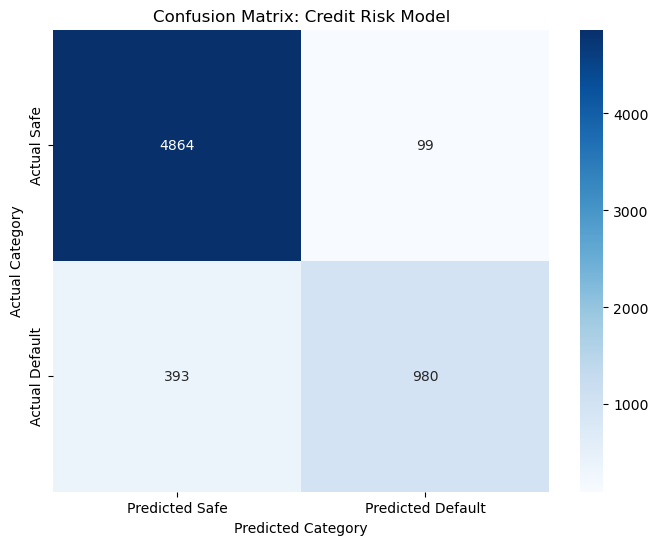


--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      4963
           1       0.91      0.71      0.80      1373

    accuracy                           0.92      6336
   macro avg       0.92      0.85      0.88      6336
weighted avg       0.92      0.92      0.92      6336



In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Plot the Confusion Matrix
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Safe', 'Predicted Default'],
            yticklabels=['Actual Safe', 'Actual Default'])
plt.title('Confusion Matrix: Credit Risk Model')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')
plt.show()

# 2. Print the text report
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))

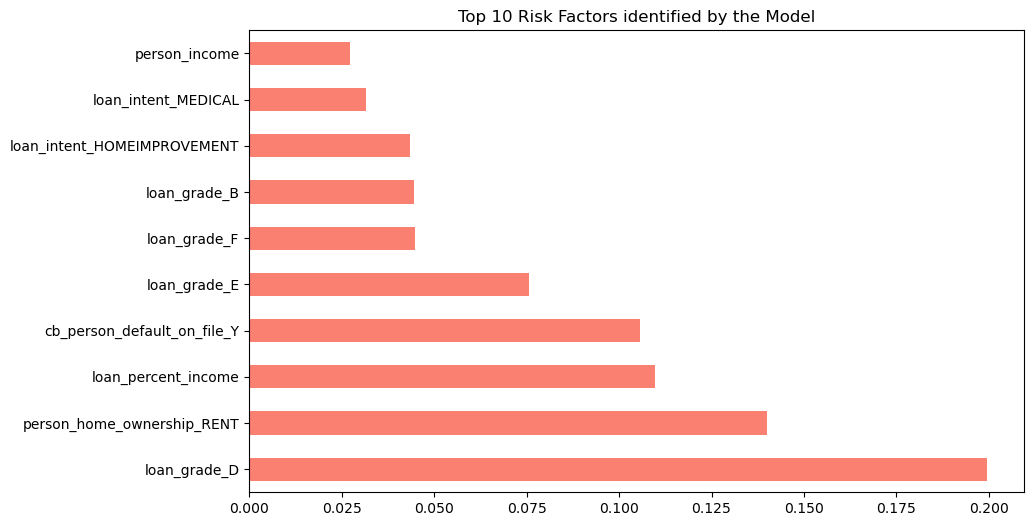

In [8]:
# Plot the top 10 most influential features
plt.figure(figsize=(10,6))
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='salmon')
plt.title('Top 10 Risk Factors identified by the Model')
plt.show()

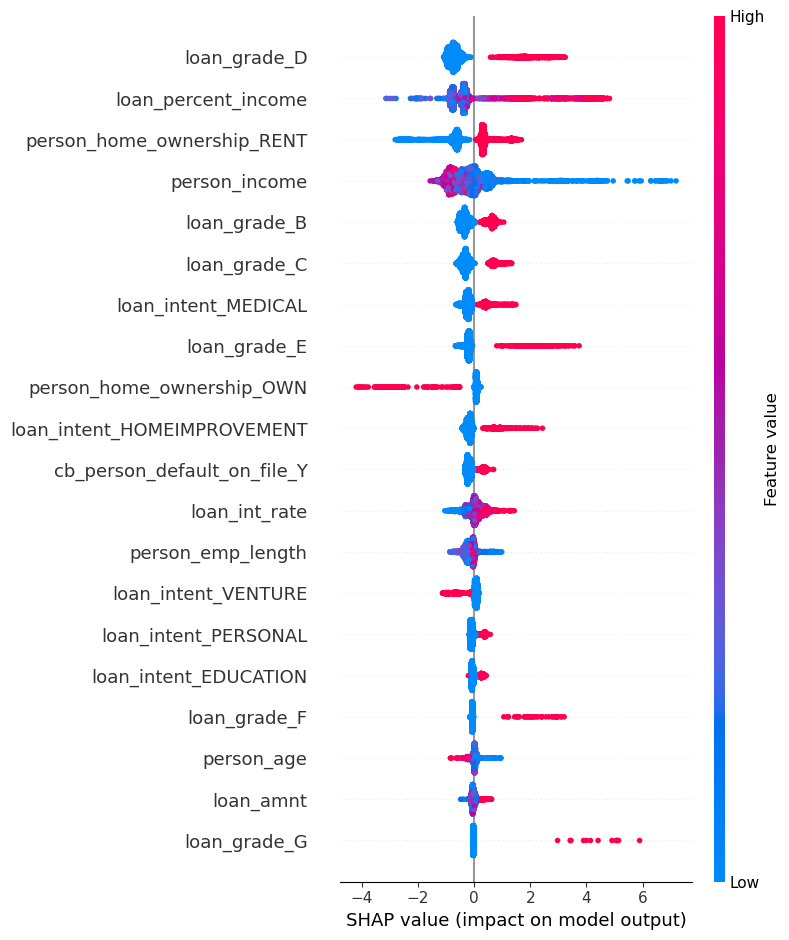

In [9]:
import shap

# Calculate SHAP values for your test set
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Visualize global feature influence
shap.summary_plot(shap_values, X_test)

In [10]:
import pickle

# Save the model to a file
with open('credit_model.pkl', 'wb') as f:
    pickle.dump(model, f)

print("✅ Model saved as 'credit_model.pkl'!")

✅ Model saved as 'credit_model.pkl'!


In [11]:
def assess_credit_risk(customer_index):
    # Get the data for one customer
    customer_data = X_test.iloc[[customer_index]]
    actual_status = y_test.iloc[customer_index]
    
    # Predictions
    pred = model.predict(customer_data)[0]
    prob = model.predict_proba(customer_data)[0][1]  # Probability of Default
    
    # Labels
    status_text = "🔴 HIGH RISK (Reject)" if pred == 1 else "🟢 LOW RISK (Approve)"
    actual_text = "❌ Defaulted" if actual_status == 1 else "✅ Paid Back"
    
    print("="*40)
    print(f"Customer Analysis (Index {customer_index})")
    print("="*40)
    print(f"Model Decision : {status_text}")
    print(f"Risk Probability : {prob*100:.2f}%")
    print(f"Actual Outcome : {actual_text}")
    print("="*40)

In [12]:
import joblib

# Use 'model' instead of 'best_model'
joblib.dump(model, 'credit_risk_model.pkl')

# Save the column names
model_columns = list(X.columns)
joblib.dump(model_columns, 'model_columns.pkl')

print("✅ Basic model saved successfully!")

✅ Basic model saved successfully!


In [13]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

# Load the model and columns we saved earlier
model = joblib.load('credit_risk_model.pkl')
cols = joblib.load('model_columns.pkl')

st.title("🏦 Credit Risk Predictor")

# --- Numeric Inputs ---
age = st.slider("Age", 18, 100, 30)
income = st.number_input("Annual Income ($)", value=50000, step=1000)
emp_length = st.slider("Employment Length (years)", 0, 40, 3)
loan_amount = st.number_input("Loan Amount ($)", value=10000, step=500)
int_rate = st.slider("Loan Interest Rate (%)", 5.0, 25.0, 12.0, step=0.1)
cred_hist_length = st.slider("Credit History Length (years)", 1, 30, 5)

# Derived feature: loan as % of income (important predictor!)
loan_percent_income = loan_amount / income if income > 0 else 0
st.info(f"Loan-to-Income Ratio: {loan_percent_income:.2%}")

# --- Categorical Inputs ---
home_ownership = st.selectbox("Home Ownership", ["RENT", "OWN", "MORTGAGE", "OTHER"])
loan_intent = st.selectbox("Loan Intent", ["PERSONAL", "EDUCATION", "MEDICAL", "VENTURE", "HOMEIMPROVEMENT", "DEBTCONSOLIDATION"])
loan_grade = st.selectbox("Loan Grade", ["A", "B", "C", "D", "E", "F", "G"])
default_on_file = st.selectbox("Previous Default on File?", ["No", "Yes"])

# --- Prediction ---
if st.button("Calculate Risk"):
    # Start with a zero-filled row matching all training columns
    full_input = pd.DataFrame(0, index=[0], columns=cols)

    # Fill numeric features
    full_input['person_age'] = age
    full_input['person_income'] = income
    full_input['person_emp_length'] = emp_length
    full_input['loan_amnt'] = loan_amount
    full_input['loan_int_rate'] = int_rate
    full_input['loan_percent_income'] = loan_percent_income
    full_input['cb_person_cred_hist_length'] = cred_hist_length

    # Fill one-hot encoded categorical features (drop_first=True means grade A, DEBTCONSOLIDATION, MORTGAGE, N are baseline)
    grade_col = f'loan_grade_{loan_grade}'
    if grade_col in full_input.columns:
        full_input[grade_col] = 1

    intent_col = f'loan_intent_{loan_intent}'
    if intent_col in full_input.columns:
        full_input[intent_col] = 1

    ownership_col = f'person_home_ownership_{home_ownership}'
    if ownership_col in full_input.columns:
        full_input[ownership_col] = 1

    if default_on_file == "Yes" and 'cb_person_default_on_file_Y' in full_input.columns:
        full_input['cb_person_default_on_file_Y'] = 1

    prediction = model.predict(full_input)[0]
    prob = model.predict_proba(full_input)[0][1]

    st.markdown("---")
    if prediction == 1:
        st.error(f"🔴 HIGH RISK — Probability of Default: {prob:.2%}")
        st.warning("Recommendation: **Reject** this loan application.")
    else:
        st.success(f"🟢 LOW RISK — Probability of Default: {prob:.2%}")
        st.info("Recommendation: **Approve** this loan application.")


Overwriting app.py


In [ ]:
!streamlit run app.py